In [1]:
import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)
import flax.nnx as nnx
import matplotlib.pyplot as plt
from typing import NamedTuple, Callable
from tqdm import tqdm

In [11]:
def u0_inviscid(x: float, uL: float, uR: float):
    return jnp.where(x==0, 0.5 * (uL + uR), jnp.where(x > 0, uR, uL))

def u0(x: float, uL: float, uR: float, nu: float):
    ans = 0.5 * (uL + uR)
    ans -= (uL-uR) * 0.5 * jnp.tanh(jnp.abs(uL-uR)*x/(4.*nu))
    return ans

In [12]:
from jax import random as jr

class UniformRandomSampler:
    """Uniform random sampler in (drho, dp, du) or any bounded rect domain."""

    def draw_batch(self, rng, batch_size: int, dim: int, bounds: jax.Array) -> jnp.ndarray:
        # bounds: shape (dim, 2), each row = [lo, hi]
        lo, hi = bounds[:, 0], bounds[:, 1]
        samples = jr.uniform(rng, (batch_size, dim), minval=0.0, maxval=1.0)
        return lo + (hi - lo) * samples

    def draw_xtu_batch(self, rng_ur, rng_xt, batch_size: int, nprob: int, bounds_ur: jax.Array, bounds_xt: jax.Array):
        ur = self.draw_batch(rng_ur, nprob, 2, bounds_ur)      # (nprob, 2)
        xt = self.draw_batch(rng_xt, batch_size, 2, bounds_xt) # (batch_size, 2)
        uL, uR = ur[:, 0], ur[:, 1]
        x, t = xt[:, 0], xt[:, 1]
        # broadcast as in original
        uL = jnp.repeat(uL, batch_size)
        uR = jnp.repeat(uR, batch_size)
        x = jnp.tile(x, nprob)
        t = jnp.tile(t, nprob)
        x_u = jnp.stack([x, t, uL, uR], axis=-1)
        x_phi = jnp.stack([x, t], axis=-1)
        return x_u, x_phi

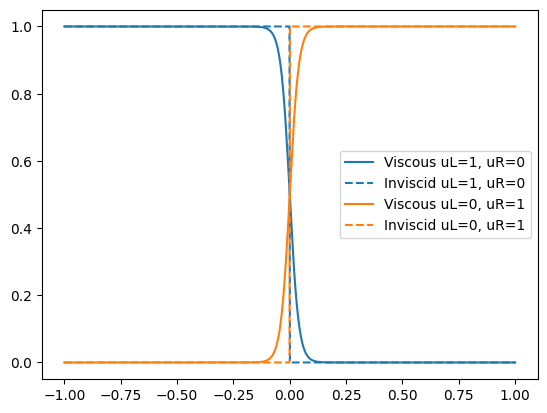

In [8]:
nu = 0.01
uL = 1.0
uR = 0.0

xlist = jnp.linspace(-1, 1, 1000)

# Plot viscous (uL=1, uR=0)
viscous_y = jax.vmap(lambda x: u0(x, uL, uR, nu))(xlist)
line, = plt.plot(xlist, viscous_y, label="Viscous uL=1, uR=0")

# Plot inviscid with dashed line and same color
inviscid_y = jax.vmap(lambda x: u0_inviscid(x, uL, uR))(xlist)
plt.plot(xlist, inviscid_y, linestyle="--", color=line.get_color(), label="Inviscid uL=1, uR=0")

# Plot another (uL=0, uR=1) case
uL2, uR2 = 0.0, 1.0
viscous_y2 = jax.vmap(lambda x: u0(x, uL2, uR2, nu))(xlist)
line2, = plt.plot(xlist, viscous_y2, label="Viscous uL=0, uR=1")

inviscid_y2 = jax.vmap(lambda x: u0_inviscid(x, uL2, uR2))(xlist)
plt.plot(xlist, inviscid_y2, linestyle="--", color=line2.get_color(), label="Inviscid uL=0, uR=1")

plt.legend()

In [10]:
class MLP(nnx.Module):
    def __init__(self, dims, *, rngs: nnx.Rngs):
        self.layers = nnx.List([nnx.Linear(dims[i], dims[i + 1], rngs=rngs) for i in range(len(dims) - 1)])

    def __call__(self, x):
        for layer in self.layers[:-1]:
            x = nnx.relu(layer(x))
        return self.layers[-1](x).squeeze(-1)


def init_nn(in_dim=4, width=32, depth=3, out_dim=1, *, seed=0):
    dims = [in_dim] + [width] * depth + [out_dim]
    return MLP(dims, rngs=nnx.Rngs(seed))

x0 = -1; x1 = 1; T = 1

u_net = init_nn()

a = jnp.array([0.1])
x_u = jnp.stack([a, a, a, a], axis=-1)
print(u_net(x_u))

[-0.0380861]


In [26]:
def loss(u, x, t, uL, uR, u0, nu, lam_ics=2.):
    # partial_t u + u * partial_x u = nu * partial_xx u
    def make_phi_and_grads(u_net):
        grad_u = jax.grad(u_net)
        u_t = lambda x: grad_u(x)[1]
        u_x = lambda x: grad_u(x)[0]
        u_xx = lambda x: jax.grad(lambda z: grad_u(z)[0])(x)[0]
        return u_t, u_x, u_xx
    
    u_t, u_x, u_xx = make_phi_and_grads(u)
    x_u = jnp.stack([x, t, uL, uR], axis=-1)
    x_u0 = jnp.stack([x, jnp.zeros_like(x), uL, uR], axis=-1)
    
    u_eval   = u(x_u)
    u0_eval  = u(x_u0)
    ut_eval  = jax.vmap(u_t)(x_u)
    ux_eval  = jax.vmap(u_x)(x_u)
    uxx_eval = jax.vmap(u_xx)(x_u)

    loss_pde = jnp.mean((ut_eval + u_eval * ux_eval - nu * uxx_eval)**2)
    loss_ics = jnp.mean((u0(x, uL, uR, nu) - u0_eval)**2)

    loss = loss_pde + lam_ics * loss_ics

    return loss

In [27]:
@nnx.jit(static_argnames=("batch_size", "nprob"))
def train_step(u_net, optimizer, key, batch_size, nprob, nu, lam_ics):
    sampler = UniformRandomSampler()
    key_ur, key_xt = jr.split(key)
    ur_bounds = jnp.array([[-1.0, 1.0], [-1.0, 1.0]])
    xt_bounds = jnp.array([[x0, x1], [0.0, T]])
    
    x_u, _ = sampler.draw_xtu_batch(key_ur, key_xt, batch_size, nprob, ur_bounds, xt_bounds)
    x, t, uL, uR = x_u[...,0], x_u[...,1], x_u[...,2], x_u[...,3]

    loss_val, grads = nnx.value_and_grad(
        lambda u_net: loss(u_net, x, t, uL, uR, u0, nu)
    )(u_net)
    optimizer.update(u_net, grads)

    return loss_val, u_net

In [44]:
def train_u(u_net, optimizer, n_steps, key, batch_size, nprob, nu, losses=[], use_tqdm=True, lam_ics=2.0):
    pbar = tqdm(range(n_steps)) if use_tqdm else range(n_steps)

    for step in pbar:
        key, sub = jax.random.split(key)
        loss_val, u_net = train_step(u_net, optimizer, sub, batch_size, nprob, nu, lam_ics)
        losses.append(float(loss_val))
        if step % 10 == 0 and use_tqdm:
            pbar.set_postfix(loss=losses[-1])
    
    return losses, u_net

In [46]:
import optax

x0 = -1; x1 = 1; T = 1
nu = 0.01


u_net = init_nn()

lr = 2e-4
n_steps = 1000

lam_ics = 5.0
nprob = 2**7
batch_size = 2**9
opt_u = nnx.Optimizer(u_net, optax.adamw(lr), wrt=nnx.Param)

key = jax.random.PRNGKey(0)
losses = []

key, sub = jax.random.split(key)
losses, u_net = train_u(u_net, opt_u, n_steps, sub, batch_size, nprob, nu, losses=losses, lam_ics=lam_ics)

100%|██████████| 1000/1000 [00:52<00:00, 19.21it/s, loss=0.0764]


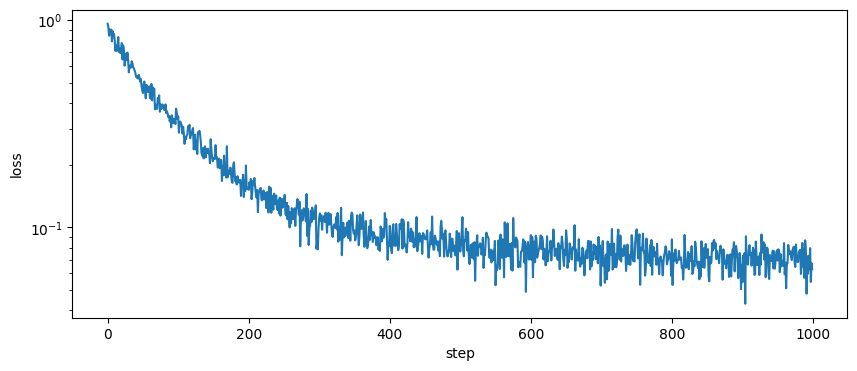

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

ax.plot(losses)
ax.set(yscale='log', xlabel='step', ylabel='loss')
plt.show()

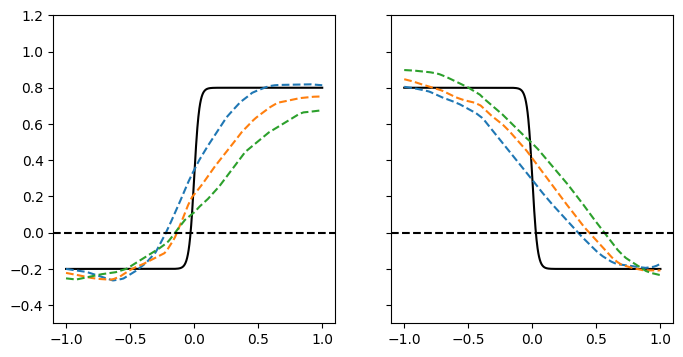

In [48]:
xlist = jnp.linspace(-1, 1, 1000)

fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

uL1 = -0.2 ; uR1 = 0.8
uL2 =  0.8 ; uR2 = -0.2
axs[0].plot(xlist, jax.vmap(lambda x: u0(x, uL1, uR1, nu))(xlist), label='uL1, uR1', c='k')
axs[1].plot(xlist, jax.vmap(lambda x: u0(x, uL2, uR2, nu))(xlist), label='uL2, uR2', c='k')

for t in [0, 0.5, 1]:
    x_u = jnp.stack([xlist, jnp.full_like(xlist, t), jnp.full_like(xlist, uL1), jnp.full_like(xlist, uR1)], axis=-1)
    axs[0].plot(xlist, u_net(x_u), '--')

    x_u = jnp.stack([xlist, jnp.full_like(xlist, t), jnp.full_like(xlist, uL2), jnp.full_like(xlist, uR2)], axis=-1)
    axs[1].plot(xlist, u_net(x_u), '--')

axs[0].set_ylim(-0.5, 1.2)
axs[0].axhline(0, c='k', ls = 'dashed')
axs[1].set_ylim(-0.5, 1.2)
axs[1].axhline(0, c='k', ls = 'dashed')
plt.show()